In [9]:
# 1) importando libs
import pandas as pd
import seaborn as sns
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib import pyplot as plt

In [10]:
# 2) criando dataframe
df = pd.read_csv("/content/dados_clientes_alta_acuracia.csv")
df

,idade,salario,comprou
0,56,10133,1
1,69,12872,1
2,46,10496,1
3,32,17958,0
4,60,6975,0
...,...,...,...
1517,39,5328,0
1518,60,19852,1
1519,63,18587,1
1520,21,14105,0


In [11]:
# tratando a base de dados
df.isnull().sum()

,0
idade,0
salario,0
comprou,0


In [12]:
# tratando a base de dados
df.drop_duplicates()

,idade,salario,comprou
0,56,10133,1
1,69,12872,1
2,46,10496,1
3,32,17958,0
4,60,6975,0
...,...,...,...
1517,39,5328,0
1518,60,19852,1
1519,63,18587,1
1520,21,14105,0


In [13]:
# tratando a base de dados
df['idade'].value_counts()

,count
idade,
50,42
43,42
68,40
64,38
66,37
45,36
54,36
52,35
18,34


In [14]:
# tratando a base de dados
df['comprou'].value_counts()

,count
comprou,
0,834
1,688


In [15]:
# tratando a base de dados
df['salario'].value_counts()

,count
salario,
18148,2
4211,2
19333,2
2783,2
13985,2
...,...
18529,1
17146,1
9492,1


In [16]:
# 3) com a base sem nenhum erro e devidamente tratada, separamos as variáveis
x = df[["idade", "salario"]]
y = df["comprou"]

In [17]:
# 4) dividir os dados em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
# 5) pré-processamento - apesar de que modelos em random forest não necessitam, mas o logistic regression SIM.
scaler = StandardScaler()
x_teste_original = x_teste.copy()  # guarda os valores originais para o gráfico
x_treino = scaler.fit_transform(x_treino)  # aprende a escala no treino e transforma
x_teste = scaler.transform(x_teste) # use .fit_transform() só no treino. no teste, use apenas .transform(). assim você não vaza informação do teste para o treino.

In [19]:
# 5) criar modelo de logistic regression e random forest
modelo_lr = LogisticRegression() #cria
modelo_lr.fit(x_treino, y_treino) #treina

modelo = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100) #cria
modelo.fit(x_treino, y_treino) # treina


RandomForestClassifier(max_depth=5, random_state=42)

In [20]:
# 7) avaliação do modelo e previsão
previsao = modelo.predict(x_teste)
acuracia = accuracy_score(y_teste, previsao)
matriz = confusion_matrix(y_teste, previsao)

previsao_lr = modelo_lr.predict(x_teste)
acuracia_lr = accuracy_score(y_teste, previsao_lr)
matriz_lr = confusion_matrix(y_teste, previsao_lr)


In [21]:
# 8) printando
print(f"Acurácia: {acuracia * 100:.2f}%")
print(f"Matriz de confusão:\n{matriz}\n")

print(f"Acurácia (LR): {acuracia_lr * 100:.2f}%")
print(f"Matriz de confusão (LR):\n{matriz_lr}\n")

Acurácia: 97.38%
Matriz de confusão:
[[166   3]
 [  5 131]]

Acurácia (LR): 82.30%
Matriz de confusão (LR):
[[148  21]
 [ 33 103]]



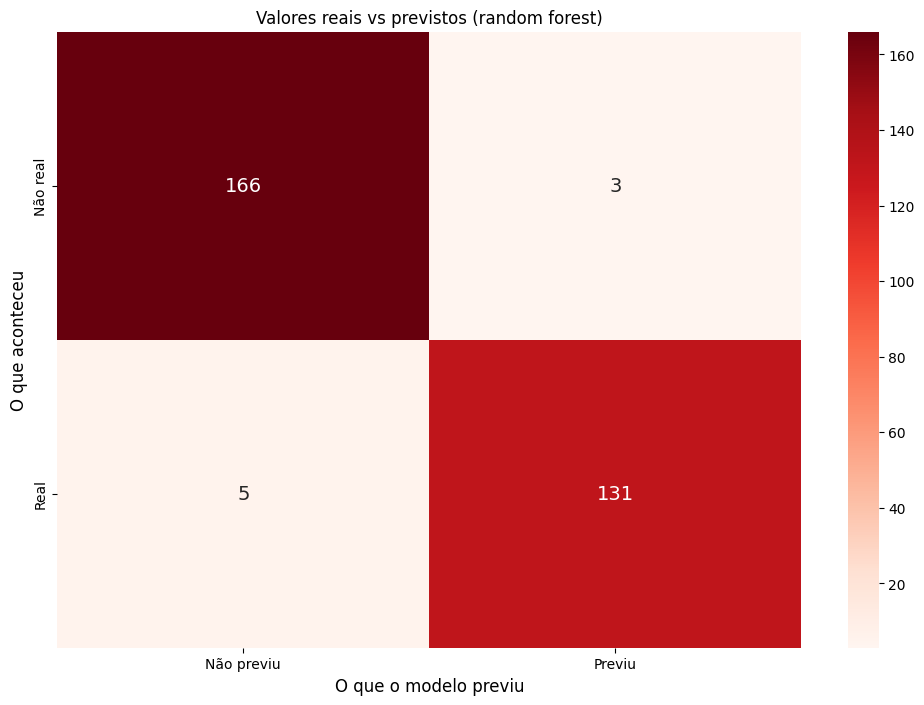

In [22]:
# 9) configurar o tamanho do gráfico
plt.figure(figsize=(12, 8))

# 10) gerando a matriz de confusão (real x previsto)
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Reds",
    xticklabels=["Não previu", "Previu"],
    yticklabels=["Não real", "Real"],
    annot_kws={"size": 14} # aumenta tamanho da fonte dos números
)

# 11) definindo titulo e label
plt.title("Valores reais vs previstos (random forest)", fontsize=12)
plt.ylabel("O que aconteceu", fontsize=12)
plt.xlabel("O que o modelo previu", fontsize=12)

# 12) Mostrar o gráfico
plt.show()

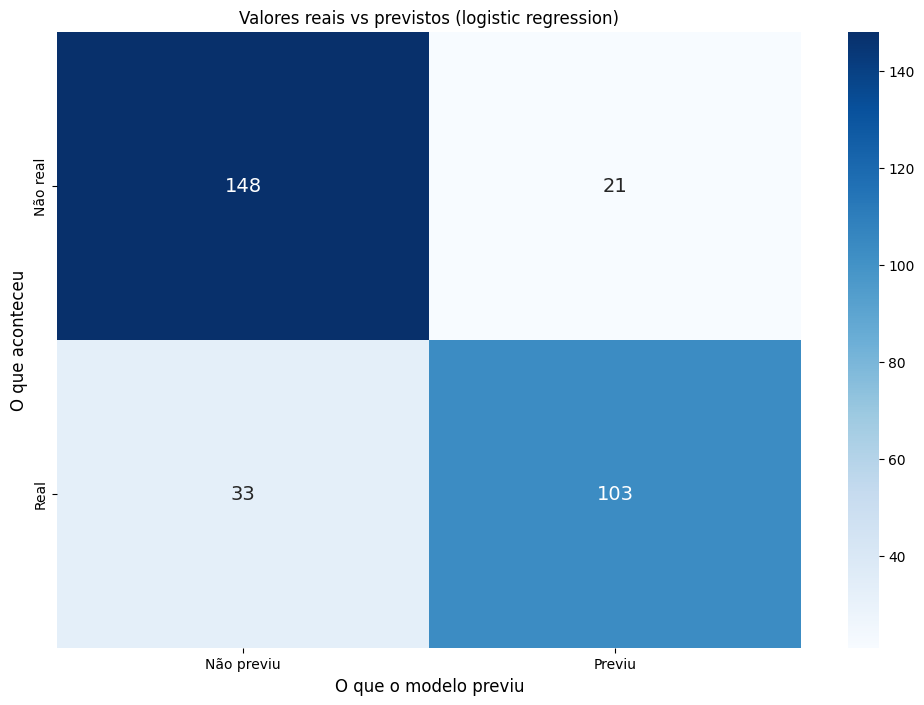

In [23]:
# 9) configurar o tamanho do gráfico
plt.figure(figsize=(12, 8))

# 10) gerando a matriz de confusão (real x previsto)
sns.heatmap(
    matriz_lr, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Não previu", "Previu"],
    yticklabels=["Não real", "Real"],
    annot_kws={"size": 14} # aumenta tamanho da fonte dos números
)

# 11) definindo titulo e label
plt.title("Valores reais vs previstos (logistic regression)", fontsize=12)
plt.ylabel("O que aconteceu", fontsize=12)
plt.xlabel("O que o modelo previu", fontsize=12)

# 12) Mostrar o gráfico
plt.show()

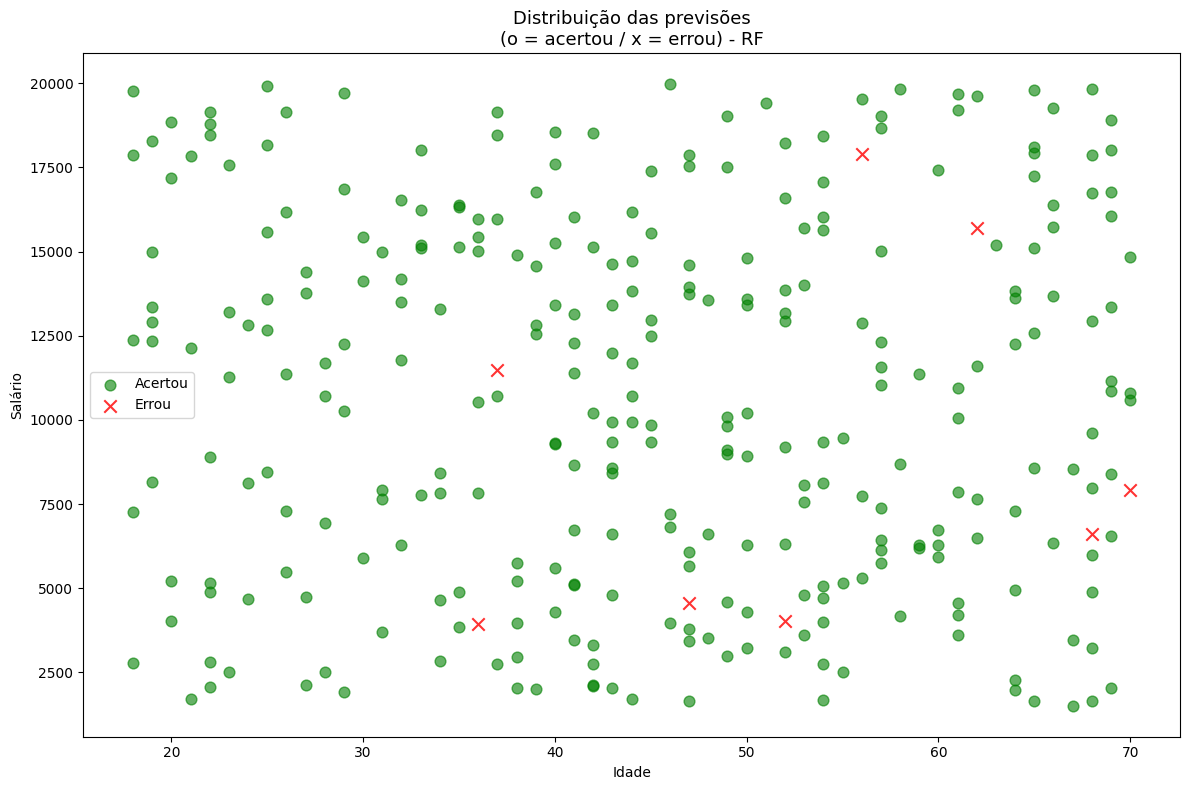

In [25]:
# 13) tamanho do gráfico
plt.figure(figsize=(12, 8))

# 14) reconstruindo o dataframe com os valores originais de idade e salário
df_plot = x_teste_original.copy()
df_plot["Real"] = y_teste.values
df_plot["Previsto"] = previsao

# 15) separando acertos e erros
acertos = df_plot[df_plot["Real"] == df_plot["Previsto"]]
erros = df_plot[df_plot["Real"] != df_plot["Previsto"]]

# 16) plotando acertos em verde (o) e erros em vermelho (x)
acertos.plot.scatter(
    x="idade", y="salario",
    c="green", marker="o", s=60,
    label="Acertou", ax=plt.gca(), alpha=0.6
)
erros.plot.scatter(
    x="idade", y="salario",
    c="red", marker="x", s=80,
    label="Errou", ax=plt.gca(), alpha=0.8
)

# 17) definindo título e labels
plt.title("Distribuição das previsões\n(o = acertou / x = errou) - RF", fontsize=13)
plt.xlabel("Idade")
plt.ylabel("Salário")
plt.legend()
plt.tight_layout()
plt.show()

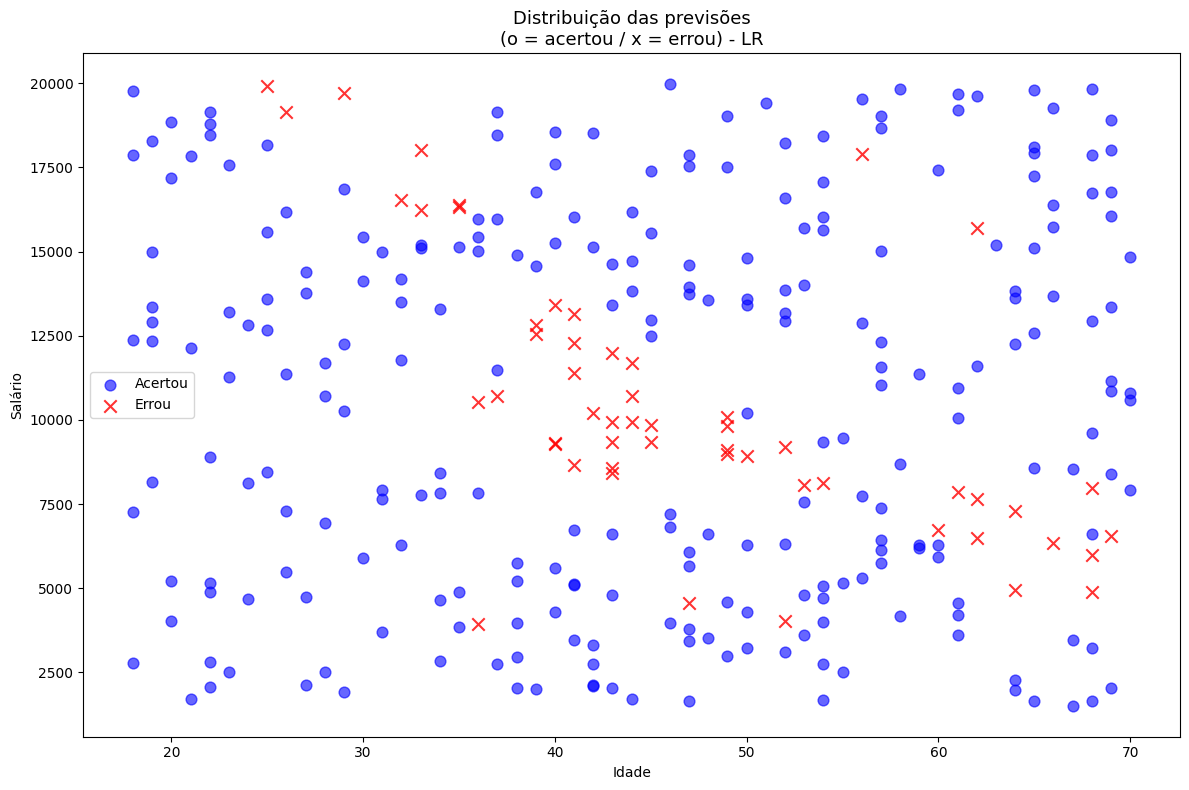

In [26]:
# 13) tamanho do gráfico
plt.figure(figsize=(12, 8))

# 14) reconstruindo o dataframe com os valores originais de idade e salário
df_plot = x_teste_original.copy()
df_plot["Real"] = y_teste.values
df_plot["Previsto"] = previsao_lr

# 15) separando acertos e erros
acertos = df_plot[df_plot["Real"] == df_plot["Previsto"]]
erros = df_plot[df_plot["Real"] != df_plot["Previsto"]]

# 16) plotando acertos em blue (o) e erros em vermelho (x)
acertos.plot.scatter(
    x="idade", y="salario",
    c="blue", marker="o", s=60,
    label="Acertou", ax=plt.gca(), alpha=0.6
)
erros.plot.scatter(
    x="idade", y="salario",
    c="red", marker="x", s=80,
    label="Errou", ax=plt.gca(), alpha=0.8
)

# 17) definindo título e labels
plt.title("Distribuição das previsões\n(o = acertou / x = errou) - LR", fontsize=13)
plt.xlabel("Idade")
plt.ylabel("Salário")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# 18) salvar modelo e scaler juntos
with open("modelo_rf.pkl", "wb") as f:
    pickle.dump(modelo, f)
with open("modelo_lr.pkl", "wb") as f:
    pickle.dump(modelo_lr, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("salvou modelos e scaler")

salvou modelos e scaler
